# Business Understanding

## Project Overview

This project focuses on predicting future retail sales using historical Walmart sales data. The dataset includes weekly sales records, store information, economic indicators, and promotional markdown data.

The goal is to build machine learning and forecasting models that can predict future weekly sales and compare their performance.

## Business Problem

Retail businesses depend on accurate sales forecasts for planning and decision-making. Poor forecasting can lead to:

* overstocking
* stock shortages
* poor staffing decisions
* revenue loss

Accurate forecasting helps businesses improve inventory management, operational planning, and revenue estimation.

## Project Objective

The main objective of this project is to:

* predict future weekly sales
* compare the performance of different forecasting models
* identify the most effective model for retail sales forecasting

## Forecasting Target

The target variable for this project is:

`Weekly_Sales`

This represents the total weekly sales generated by each store department.

## Project Approach

The project will follow these major steps:

1. Data understanding and cleaning
2. Exploratory data analysis
3. Feature engineering
4. Forecast model development
5. Model evaluation and comparison
6. Business insights and recommendations


In [1]:
# Data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame
sns.set_style('whitegrid')  # Set Seaborn style for plots

In [2]:
# Load the dataset
features_df = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/features.csv')
stores_df = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/stores.csv')
train_df = pd.read_csv('/home/emeka/projects/ML_Portfolio/retail-sales-forecasting/data/train.csv')

In [3]:
features_df.head()


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
# inspect the shape of the datasets
print(f"Features dataset shape: {features_df.shape}")
print(f"Stores dataset shape: {stores_df.shape}")
print(f"Train dataset shape: {train_df.shape}")

Features dataset shape: (8190, 12)
Stores dataset shape: (45, 3)
Train dataset shape: (421570, 5)


In [7]:
# inspect dataset info
print("Features dataset info:")
features_df.info()


Features dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [8]:
# inspect store dataset info
print("Stores dataset info:")
stores_df.info()

Stores dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [9]:
# inspect train dataset info
print("Train dataset info:")
train_df.info()

Train dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [10]:
# merge datasets
sales_df = train_df.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left').merge(stores_df, on='Store', how='left')

In [11]:
sales_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [12]:
# inspect sales dataset shape and info
print(f"Sales dataset shape: {sales_df.shape}")
print("\nSales dataset info:")
sales_df.info()

Sales dataset shape: (421570, 16)

Sales dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), ob

In [13]:
# inspecting null values in the sales dataset
print("Null values in sales dataset:")
print(sales_df.isnull().sum())

Null values in sales dataset:
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


# Phase 2 — Data Understanding

The Walmart forecasting dataset consists of three separate datasets:

* `train.csv` containing historical weekly sales records
* `features.csv` containing economic indicators and promotional markdown data
* `stores.csv` containing store-level metadata

During this phase, the datasets were inspected to understand their structure, relationships, and business meaning before preprocessing and modeling.

## Key Observations

* The `train` dataset contains the target variable `Weekly_Sales` along with store, department, and date information.
* The `features` dataset contains external factors such as temperature, fuel price, CPI, unemployment, and promotional markdown variables.
* The `stores` dataset contains store type and store size information.

The datasets were merged using common columns to create a single master forecasting dataset.

## Merging Logic

* `train.csv` was merged with `features.csv` using:

  * `Store`
  * `Date`
  * `IsHoliday`

* The resulting dataset was then merged with `stores.csv` using:

  * `Store`

A left join was used to preserve all historical sales records while attaching related feature and store information.

## Merged Dataset Summary

After merging:

* the dataset contained 421,570 rows and 16 columns
* no unexpected row duplication occurred
* sales records were successfully enriched with economic and store-level features

## Missing Values

Missing values were mainly found in the markdown columns:

* `MarkDown1`
* `MarkDown2`
* `MarkDown3`
* `MarkDown4`
* `MarkDown5`

These missing values likely indicate periods where no promotional markdown activity occurred rather than data collection errors.

## Initial Understanding

The dataset represents weekly department-level sales across multiple Walmart stores. Each row corresponds to a specific:

* store
* department
* week

This structure makes the dataset suitable for retail sales forecasting and time-series machine learning tasks.


In [14]:
sales_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [15]:
# convert 'Date' column to datetime format
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%Y-%m-%d')

# comfirm the conversion
print(sales_df['Date'].dtype)

datetime64[ns]


In [16]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [17]:
# check for duplicates in the sales dataset
sales_df.duplicated().sum()

np.int64(0)

In [18]:
# inspect the percentage of missing values in the sales dataset
markdown_col = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

sales_df[markdown_col].isnull().mean()*100

MarkDown1    64.257181
MarkDown2    73.611025
MarkDown3    67.480845
MarkDown4    67.984676
MarkDown5    64.079038
dtype: float64

In [19]:
# Inspecting statistical summary
sales_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325
MarkDown3,137091.0,1439.421384,-29.1,5.08,24.6,103.99,141630.61,9623.07829
MarkDown4,134967.0,3383.168256,0.22,504.22,1481.31,3595.04,67474.85,6292.384031


In [20]:
# ivestigating negative values in the 'Weekly_Sales' column
(sales_df['Weekly_Sales'] < 0).sum()

np.int64(1285)

In [21]:
# investigating the negative values in markdown columns
for col in markdown_col:
    print(f"Negative values in {col}: {(sales_df[col] < 0).sum()}")

Negative values in MarkDown1: 0
Negative values in MarkDown2: 1311
Negative values in MarkDown3: 257
Negative values in MarkDown4: 0
Negative values in MarkDown5: 0


In [22]:
# investigate categorical columns

sales_df['Type'].value_counts()

Type
A    215478
B    163495
C     42597
Name: count, dtype: int64

In [23]:
# investigate categorical columns
sales_df['IsHoliday'].value_counts()

IsHoliday
False    391909
True      29661
Name: count, dtype: int64

# Data Cleaning

The merged sales dataset was cleaned and validated to ensure consistency before exploratory analysis and model development.

## Cleaning Steps Performed

### Date Conversion

The `Date` column was converted from object type to datetime format to support time-series analysis and forecasting operations.

### Duplicate Check

The dataset was inspected for duplicate rows after merging. No duplicate records were found, confirming that the merge process preserved dataset integrity.

### Missing Value Investigation

Missing values were mainly found in the markdown columns:

* `MarkDown1`
* `MarkDown2`
* `MarkDown3`
* `MarkDown4`
* `MarkDown5`

The markdown columns showed high percentages of missing values, suggesting that promotional markdown activities were not active during many periods rather than indicating broken data collection.

At this stage, markdown null values were investigated but not yet filled pending further analysis during EDA.

### Statistical Validation

Summary statistics were inspected to identify unusual values and possible anomalies.

The analysis revealed:

* negative values in `Weekly_Sales`
* small negative values in `MarkDown2` and `MarkDown3`

These values were not removed because they may represent legitimate retail business events such as:

* product returns
* refunds
* accounting adjustments
* promotional corrections

### Categorical Validation

Categorical columns were inspected for inconsistencies.

* `Type` contained only valid categories: `A`, `B`, and `C`
* `IsHoliday` contained only boolean values: `True` and `False`

No formatting or category inconsistencies were found.

## Cleaning Outcome

After validation and cleaning:

* the dataset remained structurally consistent
* no duplicate rows were introduced
* data types were corrected
* business-related anomalies were identified and documented
* the dataset was prepared for exploratory data analysis


# **Exploratory Data Analysis**

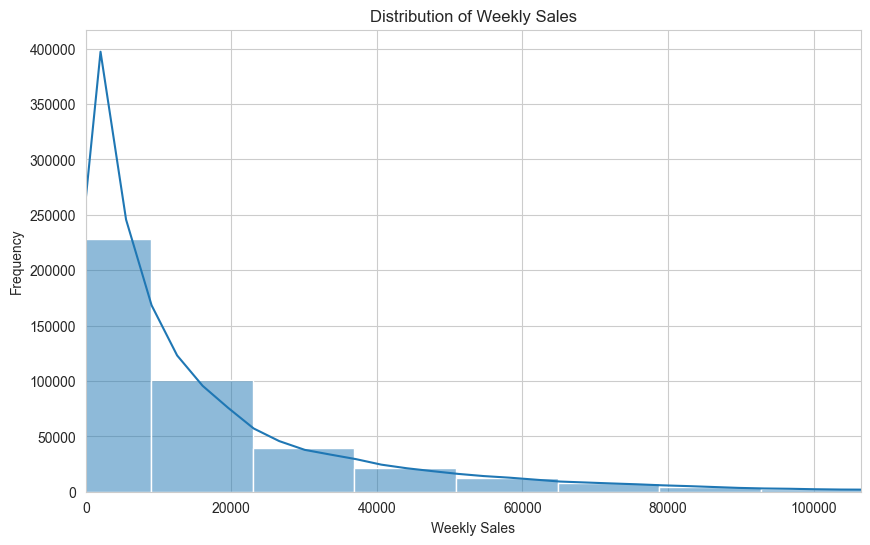

In [24]:
# investigating the distribution of 'Weekly_Sales'
plt.figure(figsize=(10, 6))
sns.histplot(sales_df['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.xlim(0, sales_df['Weekly_Sales'].quantile(0.99))  # Limit x-axis to the 99th percentile to reduce skewness  
plt.savefig('../visuals/weekly_sales_distribution.png')
plt.show()

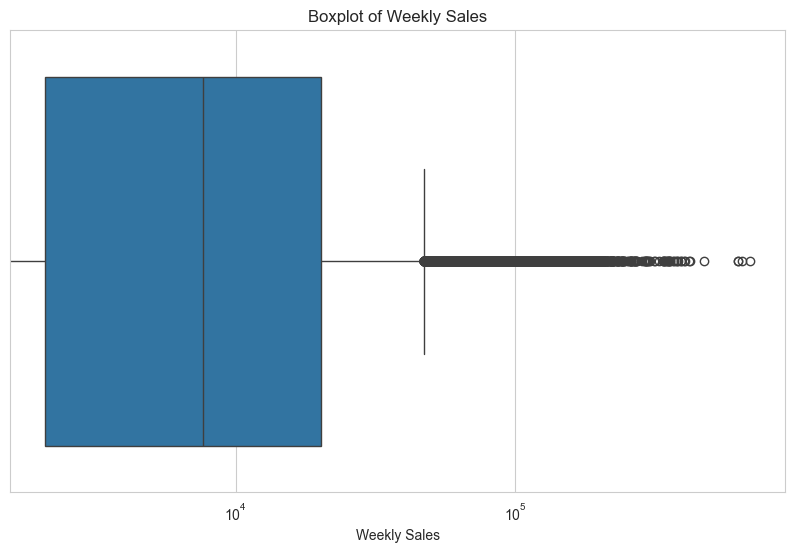

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=sales_df['Weekly_Sales'])
plt.title('Boxplot of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.savefig('../visuals/weekly_sales_boxplot.png')
plt.xscale('log')  # Use logarithmic scale to better visualize the distribution
plt.show()


## Observation on Weekly Sales

The `Weekly_Sales` distribution is heavily right-skewed. Most sales values are concentrated at lower ranges, while a smaller number of records contain very high sales values.

The histogram showed a long right tail, indicating that sales are not normally distributed. The boxplot also revealed many extreme outliers in the upper range.

These unusually high sales values may be associated with:

* holiday periods
* promotional activities
* seasonal demand
* high-performing stores or departments

The outliers were not removed because they appear to represent valid business transactions and may contain important forecasting information.

Overall, the sales data shows high variability and fluctuating sales patterns across stores and departments.


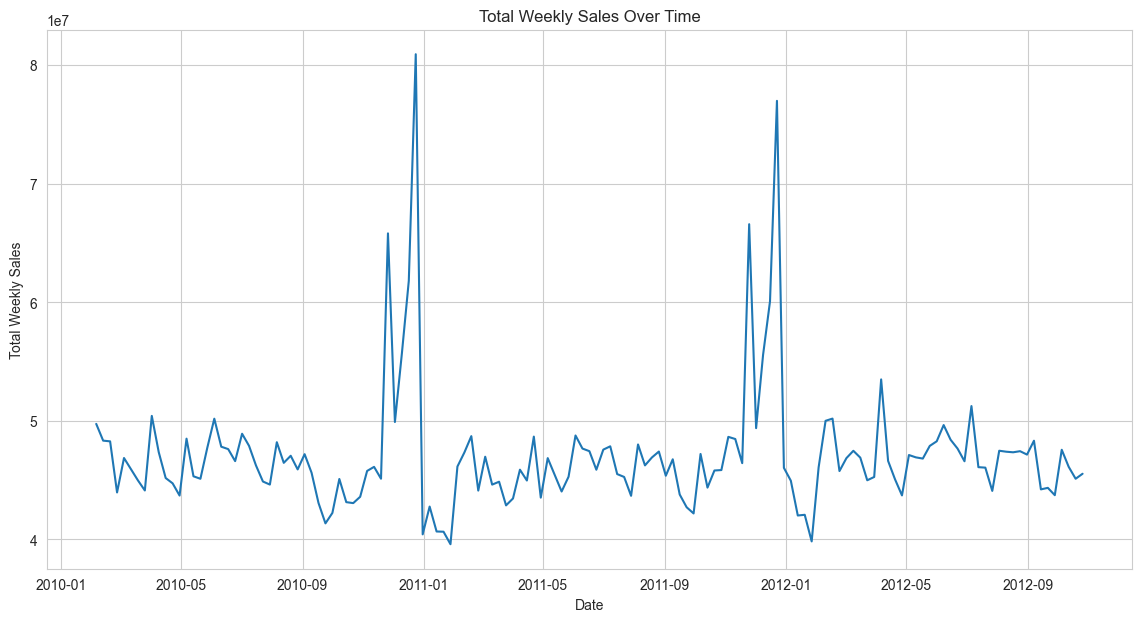

In [26]:
# Time_series analysis of 'Weekly_Sales' over time

# aggregate weekly sales by date
weekly_sales = sales_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# plotting the time series of weekly sales
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Weekly_Sales', data=weekly_sales)
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.savefig('../visuals/weekly_sales_time_series.png')
plt.show()

## Weekly Sales Trend Over Time

The sales trend plot shows that weekly sales fluctuate over time with several large spikes occurring during specific periods of the year.

The spikes appear to repeat around similar periods each year, suggesting the presence of seasonal sales patterns. These spikes may be influenced by:

* holiday shopping periods
* promotional campaigns
* seasonal customer demand

Outside the spike periods, weekly sales remain within a relatively stable range, indicating consistent baseline business activity.

The recurring sales patterns suggest that the dataset contains learnable time-based behavior, making it suitable for forecasting and time-series modeling.


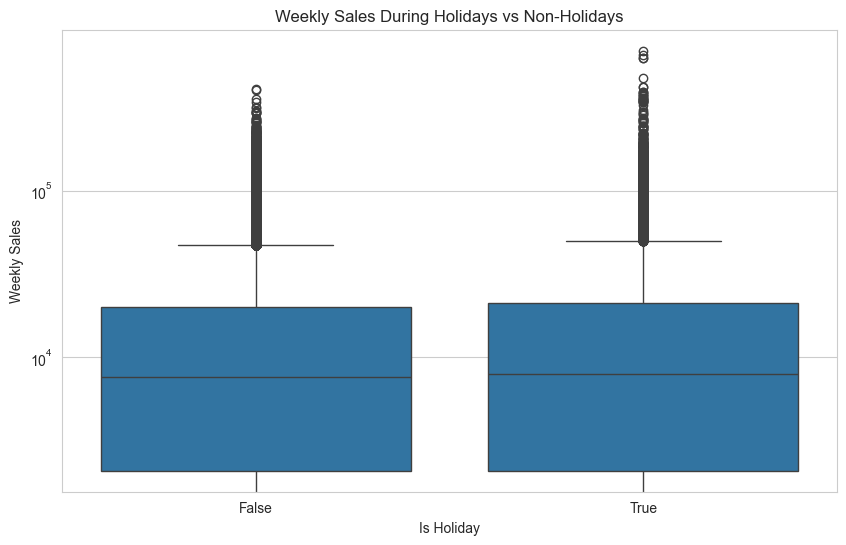

In [27]:
# compare weekly sales during holidays vs non-holidays
plt.figure(figsize=(10, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=sales_df)
plt.title('Weekly Sales During Holidays vs Non-Holidays')
plt.xlabel('Is Holiday')
plt.ylabel('Weekly Sales')
plt.yscale('log')  # Use logarithmic scale to better visualize the distribution
plt.savefig('../visuals/weekly_sales_holiday_comparison.png')
plt.show()
 

## Holiday vs Non-Holiday Sales Analysis

The comparison between holiday and non-holiday weeks shows that both groups have similar median sales values. However, holiday weeks contain slightly more extreme upper-tail outliers.

This suggests that holiday periods may not consistently increase sales across all stores and departments, but they are associated with occasional large sales spikes.

The holiday group also shows slightly higher variability, indicating that sales behavior becomes more volatile during holiday periods.

Overall, the plot supports the earlier observation that seasonal and holiday-related events may contribute to unusually high sales activity in the dataset.


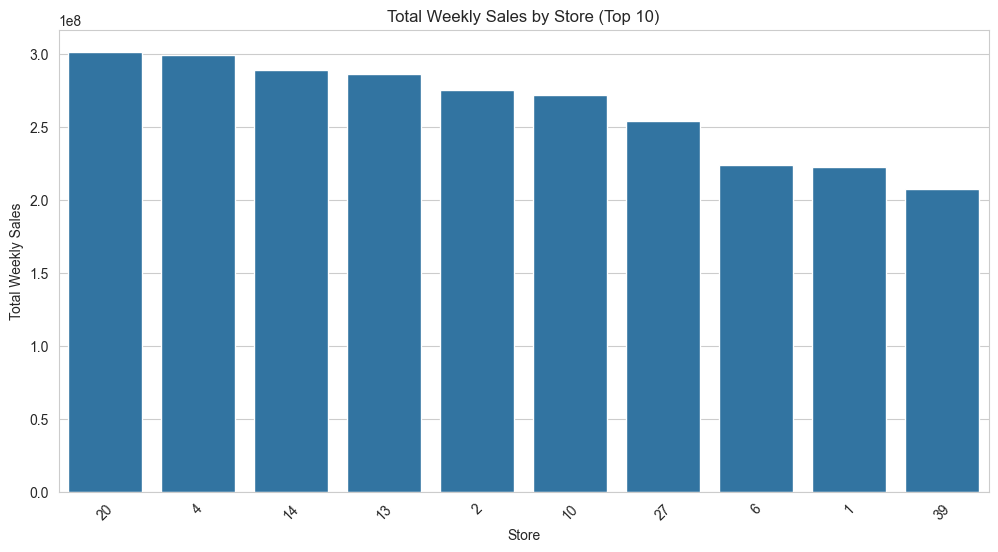

In [28]:
# calculate total sales for each store
total_sales_by_store = sales_df.groupby('Store')['Weekly_Sales'].sum().reset_index().sort_values(by='Weekly_Sales', ascending=False)

# plot total sales by store
plt.figure(figsize=(12, 6))
sns.barplot(x='Store', y='Weekly_Sales', data=total_sales_by_store.head(10), order=total_sales_by_store.head(10)['Store'])  # Plotting top 10 stores
plt.title('Total Weekly Sales by Store (Top 10)')
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.savefig('../visuals/total_sales_by_store.png')
plt.show()

## Store-Level Sales Analysis

The sales distribution across stores is not uniform. Some stores generate noticeably higher total sales than others, indicating differences in store performance across the business.

Although a few stores lead in total sales, the gap between the top-performing stores is not extremely large. This suggests that sales activity is distributed across multiple strong-performing stores rather than being dominated by a single location.

The differences in store sales may be influenced by factors such as:

* store size
* store type
* customer traffic
* regional demand
* promotional activities

The analysis also suggests that sales behavior varies across stores, which may be important for forecasting and future feature engineering.


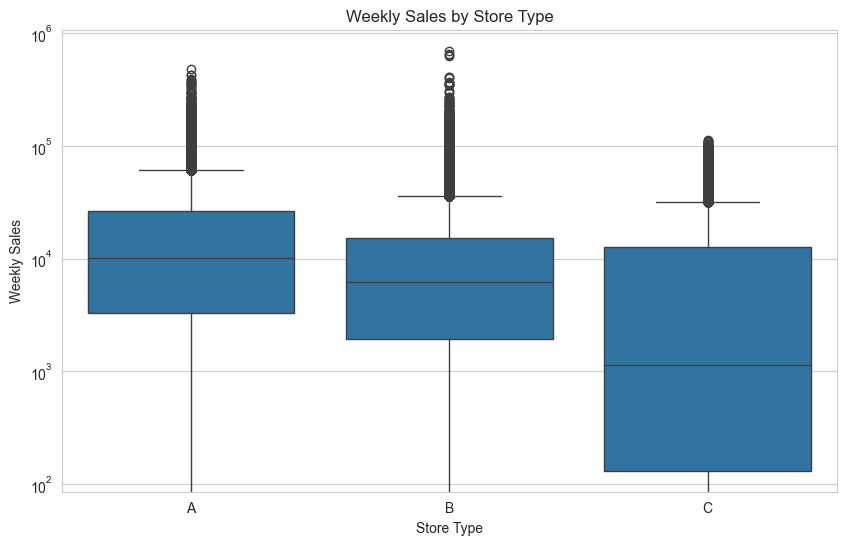

In [29]:
# Compare weekly sales by store type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=sales_df)
plt.title('Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.yscale('log')  # Use logarithmic scale to better visualize the distribution
plt.savefig('../visuals/weekly_sales_by_store_type.png')
plt.show()

## Weekly Sales by Store Type

The sales distribution differs across store types, indicating that store classification may influence sales performance.

Store Type A shows the highest median sales and contains many extreme upper-tail outliers, suggesting that these stores generally generate higher sales and experience larger sales spikes.

Store Type B also shows high variability and several large outliers, although its overall sales distribution appears slightly lower than Type A.

Store Type C has the lowest median sales and smaller upper-tail values, suggesting lower overall sales activity compared to the other store types.

The differences between store types may be influenced by factors such as:

* store size
* product variety
* customer traffic
* store location

Overall, the analysis suggests that store type may be an important feature for forecasting sales behavior.


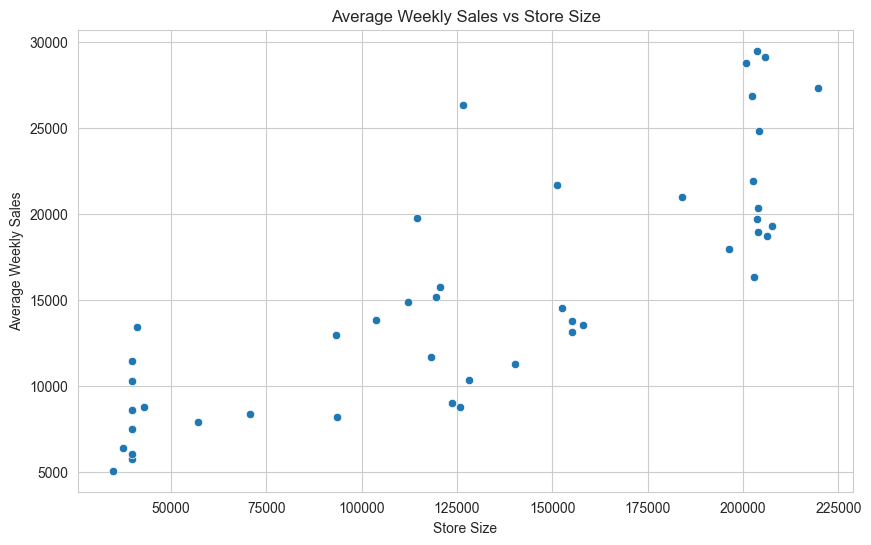

In [30]:
# calculate average weekly sales for each store
store_summary = sales_df.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'Size': 'first'
}).reset_index()

# plot average weekly sales vs store size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Weekly_Sales', data=store_summary)
plt.title('Average Weekly Sales vs Store Size')
plt.xlabel('Store Size')
plt.ylabel('Average Weekly Sales')
plt.savefig('../visuals/average_weekly_sales_vs_store_size.png')
plt.show()

## Store Size vs Average Weekly Sales

The scatterplot shows a positive relationship between store size and average weekly sales. In general, larger stores tend to generate higher sales compared to smaller stores.

The relationship appears moderate to strong, although stores with similar sizes sometimes produce different sales levels. This suggests that store size influences sales performance, but it is not the only factor affecting sales behavior.

The plot also shows possible clustering between small, medium, and large stores, which may reflect differences in store categories or operational scale.

Some smaller stores still achieve relatively strong sales performance, indicating that additional factors such as:

* store type
* location
* customer demand
* promotional activities

may also influence sales outcomes.

Overall, store size appears to be an important feature for understanding and forecasting retail sales behavior.


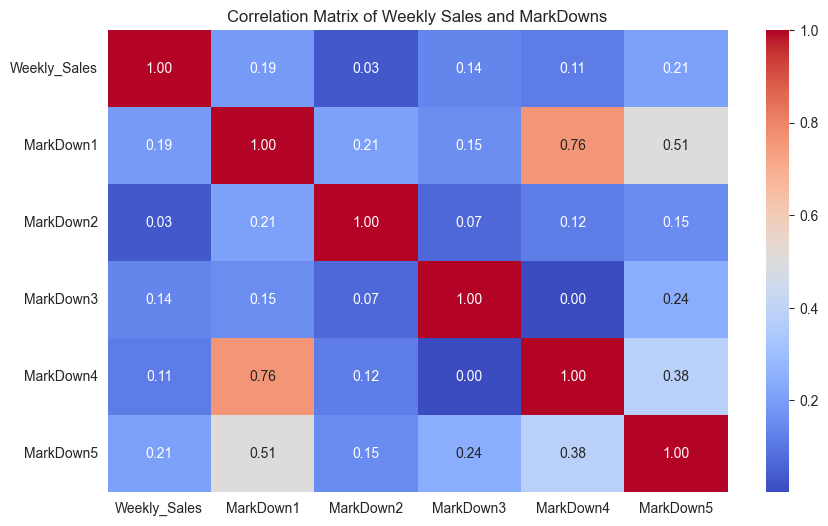

In [31]:
# select sales and markdown columns
markdown_analysis = sales_df[
    [
        'Weekly_Sales',
        'MarkDown1',
        'MarkDown2',
        'MarkDown3',
        'MarkDown4',
        'MarkDown5'
    ]
]

# calculate correlation matrix
markdown_corr = markdown_analysis.corr(method='spearman')

# plot heatmap of correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(markdown_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Weekly Sales and MarkDowns')
plt.savefig('../visuals/markdown_correlation_heatmap.png')
plt.show()

## Markdown and Sales Correlation Analysis

Spearman correlation was used to better capture relationships between markdown features and weekly sales because the sales data is highly skewed and contains extreme outliers.

The analysis shows that `MarkDown1` and `MarkDown5` have the strongest positive relationships with `Weekly_Sales`, although the correlations remain relatively weak to moderate. This suggests that promotional markdown activities may influence sales, but the relationship is not strictly linear.

The heatmap also reveals a strong positive relationship between `MarkDown1` and `MarkDown4`, indicating that these markdown campaigns may occur together or represent related promotional strategies.

Overall, the results suggest that markdown activities may contribute to sales performance, but their effects likely depend on additional factors such as:

* holidays
* seasonality
* store behavior
* customer demand patterns


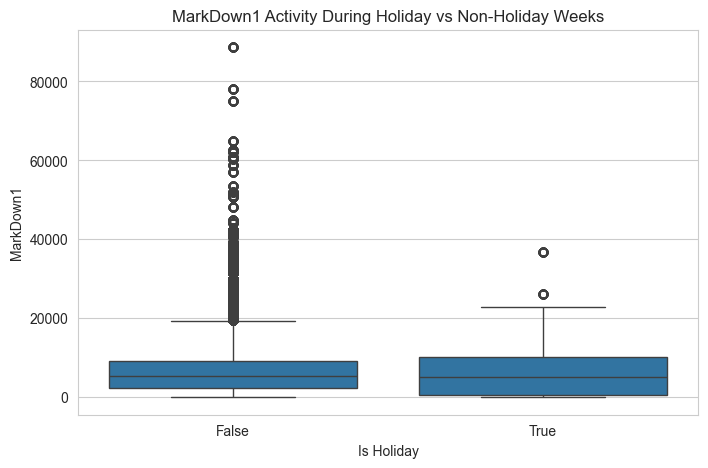

In [32]:
# create figure size
plt.figure(figsize=(8,5))

# compare markdown activity during holiday and non-holiday weeks
sns.boxplot(x='IsHoliday', y='MarkDown1', data=sales_df)
plt.title('MarkDown1 Activity During Holiday vs Non-Holiday Weeks')
plt.xlabel('Is Holiday')
plt.ylabel('MarkDown1')
plt.savefig('../visuals/markdown1_holiday_comparison.png')
plt.show()

## MarkDown1 Activity During Holiday and Non-Holiday Weeks

The distribution of `MarkDown1` appears relatively similar between holiday and non-holiday periods. Holiday weeks do not show a dramatic increase in markdown activity compared to non-holiday weeks.

The non-holiday group contains more extreme upper-tail outliers, indicating that some large promotional campaigns also occur outside holiday periods.

This suggests that markdown activity may be part of Walmart’s regular promotional strategy rather than being limited only to holiday events.

The analysis also indicates that holiday sales spikes observed earlier may not be driven entirely by markdown activity alone, and other seasonal customer behaviors may also influence sales performance.


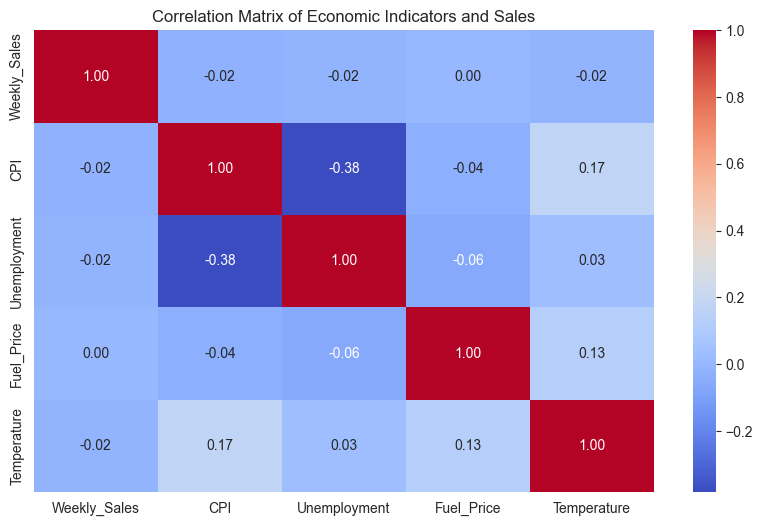

In [33]:
# select economic and sales columns
economic_df = sales_df[
    ['Weekly_Sales', 'CPI', 'Unemployment', 'Fuel_Price', 'Temperature']
]

# calculate correlation matrix
economic_corr = economic_df.corr(method='spearman')

# Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(economic_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Economic Indicators and Sales')
plt.savefig('../visuals/economic_correlation_heatmap.png')
plt.show()

## Economic Indicators and Sales Analysis

The correlation analysis shows that the economic variables have very weak relationships with weekly sales. CPI, unemployment, fuel price, and temperature all display correlations close to zero with `Weekly_Sales`.

This suggests that short-term sales behavior in the dataset may be influenced more strongly by:

* seasonal demand
* holiday periods
* promotional activities
* store-level factors

rather than broader economic conditions alone.

Among the economic variables, CPI and unemployment show a moderate negative relationship with each other, indicating some interaction between economic conditions within the dataset.

Although the direct correlations with sales are weak, the economic variables may still provide useful information during modeling because machine learning models can capture nonlinear and combined relationships between features.


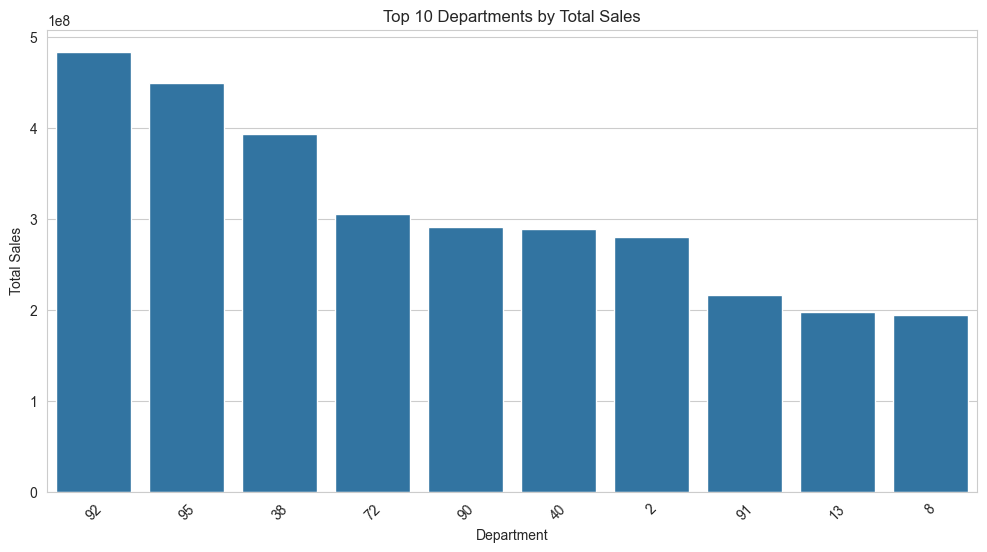

In [34]:
# calculate total sales for each department
dept_sales = (
    sales_df.groupby('Dept')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# create figure size
plt.figure(figsize=(12,6))

# plot top 10 departments by total sales
sns.barplot(
    x='Dept',
    y='Weekly_Sales',
    data=dept_sales.head(10),
    order=dept_sales.head(10)['Dept']
)

plt.title('Top 10 Departments by Total Sales')
plt.xlabel('Department')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.savefig('../visuals/top_departments_by_sales.png')
plt.show()

## Department-Level Sales Analysis

The analysis shows that sales are not evenly distributed across departments. A few departments generate significantly higher total sales compared to others, indicating differences in customer demand across product categories.

Departments 92, 95, and 38 appear to be the strongest-performing departments in the dataset, although several other departments also contribute substantial sales volume.

The variation in department performance suggests that sales behavior differs across departments and may be influenced by factors such as:

* product demand
* seasonal purchasing patterns
* promotional activities
* customer preferences

The results also indicate that department information is likely to be an important feature for forecasting retail sales behavior.


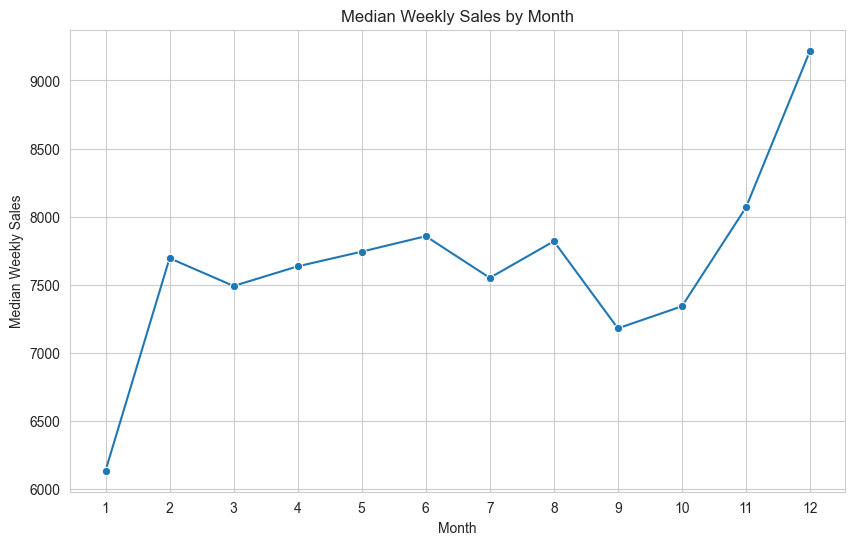

In [ ]:
# create month column from date
sales_df['Month'] = sales_df['Date'].dt.month

# calculate median sales by month
monthly_sales = sales_df.groupby('Month')['Weekly_Sales'].median().reset_index()

# plot median sales by month
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='Weekly_Sales', data=monthly_sales, marker='o')
plt.title('Median Monthly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Median monthly Sales')
plt.xticks(range(1, 13))  # Set x-ticks to represent months
plt.savefig('../visuals/median_sales_by_month.png')
plt.show()

## Median Weekly Sales by Month

The monthly sales analysis shows clear seasonal patterns in weekly sales behavior across the year.

December records the highest median weekly sales, indicating a strong increase in customer demand during the end-of-year period. This pattern may be influenced by holiday shopping activity and seasonal purchasing behavior.

January shows the lowest median sales, suggesting a sharp decline in demand following the holiday season.

From February to October, sales remain relatively stable with moderate fluctuations before increasing again toward November and December.

The recurring monthly pattern suggests that the dataset contains strong seasonal behavior, which is important for forecasting and time-series modeling.


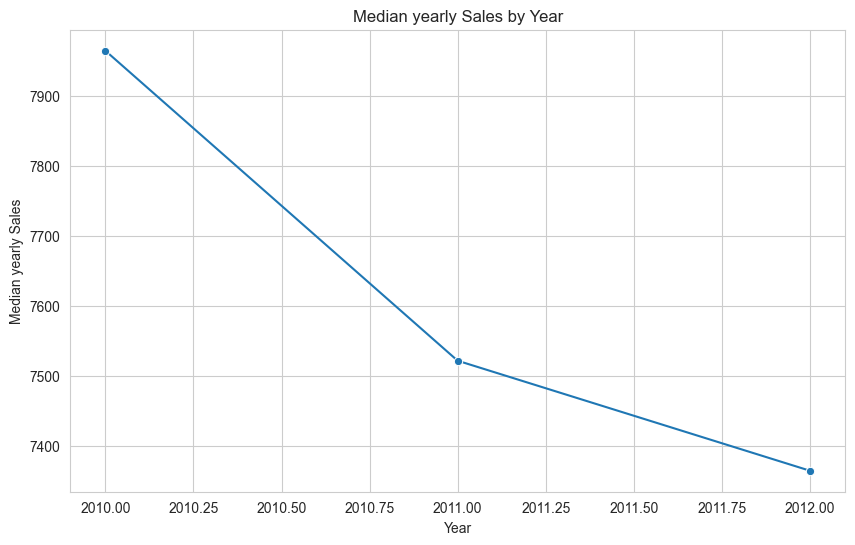

In [36]:
# Create a year column from the date
sales_df['Year'] = sales_df['Date'].dt.year

# calculate median sales by year
yearly_sales = sales_df.groupby('Year')['Weekly_Sales'].median().reset_index()

# plot median sales by year
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Weekly_Sales', data=yearly_sales, marker='o')
plt.title('Median yearly Sales by Year')
plt.xlabel('Year')
plt.ylabel('Median yearly Sales')
plt.savefig('../visuals/median_sales_by_year.png')
plt.show()

## Median Weekly Sales by Year

The yearly sales analysis shows a gradual decline in median weekly sales from 2010 to 2012.

Although the downward movement is noticeable, the decline appears moderate rather than extreme, suggesting that the business remains relatively stable overall during the observed period.

The analysis does not show evidence of strong long-term sales growth within the dataset timeframe. Instead, sales behavior appears to be influenced more strongly by recurring seasonal patterns observed earlier in the analysis.

Because the dataset covers a relatively short period, the results should be interpreted cautiously without making strong long-term business conclusions.

Overall, the findings suggest that seasonality and calendar-related patterns may play a larger role in forecasting sales behavior than long-term yearly growth trends.


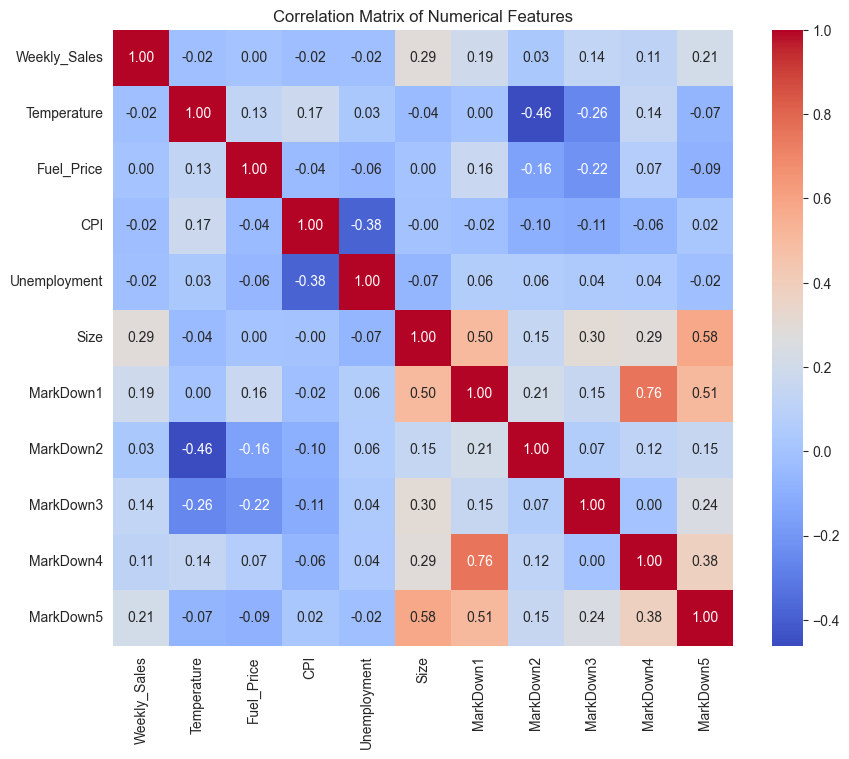

In [40]:
# select important numerical columns
numeric_df = sales_df[
    [
        'Weekly_Sales',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Size',
        'MarkDown1',
        'MarkDown2',
        'MarkDown3',
        'MarkDown4',
        'MarkDown5'
    ]
]

# calculate correlation matrix
numeric_corr = numeric_df.corr(method='spearman')

# plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('../visuals/numerical_correlation_heatmap.png')
plt.show()

## Correlation Analysis of Numerical Features

The correlation heatmap shows that most numerical variables have weak to moderate relationships with weekly sales.

`Size` has the strongest positive relationship with `Weekly_Sales`, suggesting that larger stores generally tend to generate higher sales. Several markdown features, particularly `MarkDown1` and `MarkDown5`, also show moderate positive relationships with sales.

The analysis also reveals strong relationships between some predictor variables themselves. In particular, `MarkDown1` and `MarkDown4` show a strong positive correlation, indicating possible overlap or related promotional behavior between the two features.

The weak to moderate correlations across most variables suggest that retail sales behavior is influenced by multiple interacting factors rather than a single dominant variable.

Overall, the findings indicate that:

* store-related features
* promotional activities
* seasonal patterns

may contribute more strongly to forecasting performance than the economic variables in the dataset.

The analysis also suggests the presence of some multicollinearity among markdown variables, which should be considered during feature engineering and modeling.


In [42]:
# save cleaned dataset
sales_df.to_csv('../data/cleaned_sales_data.csv', index=False)

# Key Findings from Exploratory Data Analysis

* Weekly sales distribution is heavily right-skewed with several extreme outliers.
* Strong seasonal patterns were observed, especially during the end-of-year period.
* December recorded the highest median sales, while January showed the lowest sales levels.
* Holiday periods were associated with stronger sales spikes and increased sales variability.
* Store performance varies across locations, with larger stores generally generating higher sales.
* Store Type A stores showed the strongest sales performance and larger sales spikes compared to other store types.
* Sales are not evenly distributed across departments, indicating differences in customer demand across product categories.
* Markdown features showed weak to moderate relationships with sales, suggesting that promotional effects may be more complex and nonlinear.
* Economic variables such as CPI, unemployment, fuel price, and temperature showed weak direct relationships with weekly sales.
* Several variables showed moderate relationships with each other, indicating possible multicollinearity among some markdown features.
* The dataset contains strong seasonal and time-based patterns, making it suitable for forecasting and machine learning modeling.


# EDA Conclusion

The exploratory data analysis revealed that retail sales behavior in the dataset is influenced more strongly by seasonal, promotional, and store-related factors than by the economic variables provided.

The analysis identified clear seasonal patterns, recurring sales spikes, and noticeable differences in sales performance across stores and departments. Holiday periods and promotional activities were associated with higher sales variability, although markdown features showed only weak to moderate direct relationships with sales.

Store size and store type also appeared to play important roles in sales performance, while economic indicators such as CPI, unemployment, fuel price, and temperature showed limited direct influence on weekly sales behavior.

Overall, the dataset contains meaningful time-based patterns, store-level differences, and promotional behavior that are suitable for forecasting and machine learning analysis. The findings from this EDA phase provide a strong foundation for feature engineering and predictive modeling in the next stage of the project.
